# Dynamic Routing Between Capsules (CapsNet)

**Paper:** [Sabour, Frosst & Hinton (2017)](https://arxiv.org/abs/1710.09829)

This notebook implements a Capsule Network from scratch in PyTorch, including:
- Vector-output capsules with the squashing non-linearity
- Iterative routing-by-agreement between capsule layers
- Margin loss for digit existence
- A decoder for reconstruction-based regularization
- Visualization of what individual capsule dimensions encode

**CPU-friendly:** The architecture is scaled down from the original paper for CPU execution: 64 channels in Conv1 (vs 256), 8 primary capsule types (vs 32), 2 routing iterations (vs 3), and 5 epochs. The core algorithm is identical.


## 1. Setup & Imports


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cpu')
print(f'Using device: {device}')


Using device: cpu


## 2. Data Loading & Preprocessing

We load MNIST and use a subset for faster CPU training (20K train, 5K test).


Train: 20000 samples, Test: 5000 samples


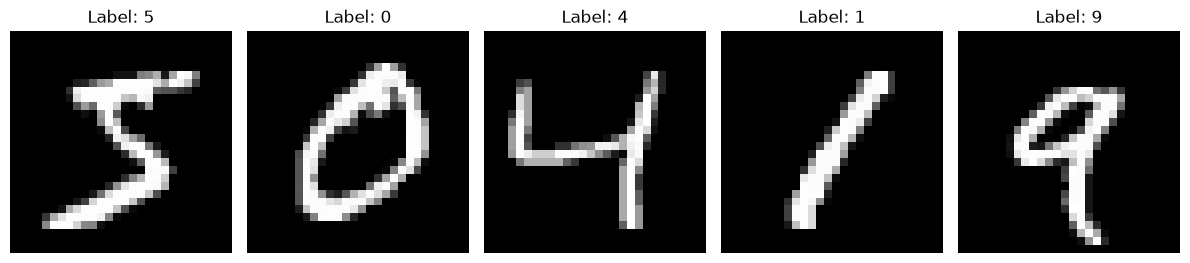

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_full = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Use subset for CPU-friendly training
train_dataset = Subset(train_full, range(20000))
test_dataset = Subset(test_full, range(5000))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f'Train: {len(train_dataset)} samples, Test: {len(test_dataset)} samples')

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Squashing Function

The squashing non-linearity (Eq. 1) preserves orientation but scales magnitude to [0, 1):

$$v_j = \frac{\|s_j\|^2}{1 + \|s_j\|^2} \cdot \frac{s_j}{\|s_j\|}$$


In [3]:
def squash(s, dim=-1, eps=1e-8):
    norm_sq = torch.sum(s ** 2, dim=dim, keepdim=True)
    norm = torch.sqrt(norm_sq + eps)
    scale = norm_sq / (1.0 + norm_sq)
    return scale * (s / norm)


## 4. PrimaryCaps Layer

Converts Conv1 scalar outputs into 4D capsule vectors. The paper uses 8D with 32 types; we use 4D with 8 types for CPU efficiency. The mechanism is identical.


In [4]:
class PrimaryCapsule(nn.Module):
    def __init__(self, in_channels=64, dim_capsule=4, kernel_size=9, stride=2, num_capsule_types=8):
        super().__init__()
        self.dim_capsule = dim_capsule
        self.num_capsule_types = num_capsule_types
        self.conv = nn.Conv2d(in_channels, num_capsule_types * dim_capsule, kernel_size=kernel_size, stride=stride)

    def forward(self, x):
        # x: [B, 64, 20, 20]
        out = self.conv(x)  # [B, 8*4, 6, 6]
        B = out.size(0)
        out = out.view(B, self.num_capsule_types, self.dim_capsule, -1)  # [B, 8, 4, 36]
        out = out.permute(0, 1, 3, 2).contiguous()  # [B, 8, 36, 4]
        out = out.view(B, -1, self.dim_capsule)  # [B, 288, 4]
        out = squash(out, dim=-1)
        return out


## 5. DigitCaps Layer with Dynamic Routing

The core of the paper: 10 capsules (one per digit class), each producing an 8D vector. We use 8D (vs 16D in paper) and 2 routing iterations (vs 3) for CPU speed. The routing algorithm is identical.


In [5]:
class DigitCapsule(nn.Module):
    def __init__(self, num_primary_caps=288, primary_dim=4, num_classes=10, class_dim=8, routing_iters=2):
        super().__init__()
        self.num_primary_caps = num_primary_caps
        self.primary_dim = primary_dim
        self.num_classes = num_classes
        self.class_dim = class_dim
        self.routing_iters = routing_iters
        # W: [1, 10, 288, 8, 4] — transforms each primary 4D -> 8D prediction
        self.W = nn.Parameter(torch.randn(1, num_classes, num_primary_caps, class_dim, primary_dim) * 0.01)

    def forward(self, x):
        # x: [B, 288, 4]
        B = x.size(0)
        # Expand: [B, 1, 288, 4] -> [B, 10, 288, 4]
        x = x.unsqueeze(1).expand(B, self.num_classes, self.num_primary_caps, self.primary_dim)
        # [B, 10, 288, 1, 4] for matmul
        x = x.unsqueeze(3)  # [B, 10, 288, 1, 4]
        # W: [1, 10, 288, 8, 4] -> [B, 10, 288, 8, 4]
        W = self.W.expand(B, -1, -1, -1, -1)
        # u_hat = W @ x^T: [B, 10, 288, 8, 1] -> squeeze -> [B, 10, 288, 8]
        u_hat = torch.matmul(W, x.transpose(-1, -2)).squeeze(-1)

        b = torch.zeros(B, self.num_classes, self.num_primary_caps, 1, device=x.device)

        for i in range(self.routing_iters):
            c = F.softmax(b, dim=1)  # [B, 10, 288, 1]
            s = (c * u_hat).sum(dim=2, keepdim=True)  # [B, 10, 1, 8]
            v = squash(s, dim=-1)  # [B, 10, 1, 8]
            if i < self.routing_iters - 1:
                b = b + (u_hat * v).sum(dim=-1, keepdim=True)

        v = v.squeeze(2)  # [B, 10, 8]
        return v


## 6. Margin Loss

For each digit class k:

$$L_k = T_k \cdot \max(0, m^+ - \|v_k\|)^2 + \lambda (1 - T_k) \cdot \max(0, \|v_k\| - m^-)^2$$

with $m^+ = 0.9$, $m^- = 0.1$, $\lambda = 0.5$.


In [6]:
class MarginLoss(nn.Module):
    def __init__(self, m_plus=0.9, m_minus=0.1, lambda_val=0.5):
        super().__init__()
        self.m_plus = m_plus
        self.m_minus = m_minus
        self.lambda_val = lambda_val

    def forward(self, v, labels):
        B = v.size(0)
        v_norm = torch.sqrt((v ** 2).sum(dim=-1) + 1e-8)
        T = F.one_hot(labels, num_classes=10).float()
        positive_loss = T * F.relu(self.m_plus - v_norm) ** 2
        negative_loss = (1 - T) * F.relu(v_norm - self.m_minus) ** 2
        loss = positive_loss + self.lambda_val * negative_loss
        return loss.sum(dim=1).mean()


## 7. Decoder (Reconstruction Regularizer)

Takes the masked DigitCaps output and reconstructs the input image.


In [7]:
class Decoder(nn.Module):
    def __init__(self, class_dim=8, output_size=784):
        super().__init__()
        self.fc1 = nn.Linear(class_dim, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc3 = nn.Linear(512, output_size)

    def forward(self, v):
        h = F.relu(self.fc1(v))
        h = F.relu(self.fc2(h))
        out = torch.sigmoid(self.fc3(h))
        return out.view(-1, 1, 28, 28)


## 8. Full CapsNet Model


In [8]:
class CapsNet(nn.Module):
    def __init__(self, routing_iters=2):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=9, stride=1)
        self.primary_caps = PrimaryCapsule(in_channels=64, dim_capsule=4, kernel_size=9, stride=2, num_capsule_types=8)
        self.digit_caps = DigitCapsule(num_primary_caps=288, primary_dim=4, num_classes=10, class_dim=8, routing_iters=routing_iters)
        self.decoder = Decoder(class_dim=8, output_size=784)

    def forward(self, x, labels=None):
        h = F.relu(self.conv1(x))
        primary = self.primary_caps(h)
        digit = self.digit_caps(primary)

        if labels is not None:
            idx = F.one_hot(labels, num_classes=10).bool().unsqueeze(2)
        else:
            v_norm = torch.sqrt((digit ** 2).sum(dim=-1) + 1e-8)
            pred = v_norm.argmax(dim=1)
            idx = F.one_hot(pred, num_classes=10).bool().unsqueeze(2)

        masked = (digit * idx.float()).sum(dim=1)
        reconstruction = self.decoder(masked)
        return digit, reconstruction

    def predict(self, x):
        digit, _ = self.forward(x)
        v_norm = torch.sqrt((digit ** 2).sum(dim=-1) + 1e-8)
        return v_norm.argmax(dim=1)


### Model Summary


In [9]:
model = CapsNet(routing_iters=2).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(model)


Total parameters: 799,408
CapsNet(
  (conv1): Conv2d(1, 64, kernel_size=(9, 9), stride=(1, 1))
  (primary_caps): PrimaryCapsule(
    (conv): Conv2d(64, 32, kernel_size=(9, 9), stride=(2, 2))
  )
  (digit_caps): DigitCapsule()
  (decoder): Decoder(
    (fc1): Linear(in_features=8, out_features=256, bias=True)
    (fc2): Linear(in_features=256, out_features=512, bias=True)
    (fc3): Linear(in_features=512, out_features=784, bias=True)
  )
)


## 9. Training Loop

5 epochs with Adam (lr=1e-3). Total loss = Margin Loss + 0.0005 * Reconstruction MSE.


In [10]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
margin_loss_fn = MarginLoss(m_plus=0.9, m_minus=0.1, lambda_val=0.5)
recon_weight = 0.0005
num_epochs = 5
train_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    for batch_idx, (data, labels) in enumerate(train_loader):
        data, labels = data.to(device), labels.to(device)
        optimizer.zero_grad()
        digit, recon = model(data, labels)
        m_loss = margin_loss_fn(digit, labels)
        r_loss = F.mse_loss(recon, data)
        loss = m_loss + recon_weight * r_loss
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        num_batches += 1
        if (batch_idx + 1) % 100 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Batch {batch_idx+1}, Loss: {loss.item():.4f}')
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            preds = model.predict(data)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    test_acc = 100.0 * correct / total
    test_accuracies.append(test_acc)
    print(f'Epoch {epoch+1}/{num_epochs} - Avg Loss: {avg_loss:.4f}, Test Accuracy: {test_acc:.2f}%')

print(f'\nFinal Test Accuracy: {test_accuracies[-1]:.2f}%')


Epoch 1/5, Batch 100, Loss: 0.1402


Epoch 1/5, Batch 200, Loss: 0.0435


Epoch 1/5, Batch 300, Loss: 0.0386


Epoch 1/5 - Avg Loss: 0.1231, Test Accuracy: 96.28%


Epoch 2/5, Batch 100, Loss: 0.0359


...

Epoch 4/5 - Avg Loss: 0.0183, Test Accuracy: 98.14%


Epoch 5/5, Batch 100, Loss: 0.0197


Epoch 5/5, Batch 200, Loss: 0.0081


Epoch 5/5, Batch 300, Loss: 0.0100


Epoch 5/5 - Avg Loss: 0.0151, Test Accuracy: 98.16%

Final Test Accuracy: 98.16%


## 10. Evaluation & Visualization

### 10.1 Training Curves


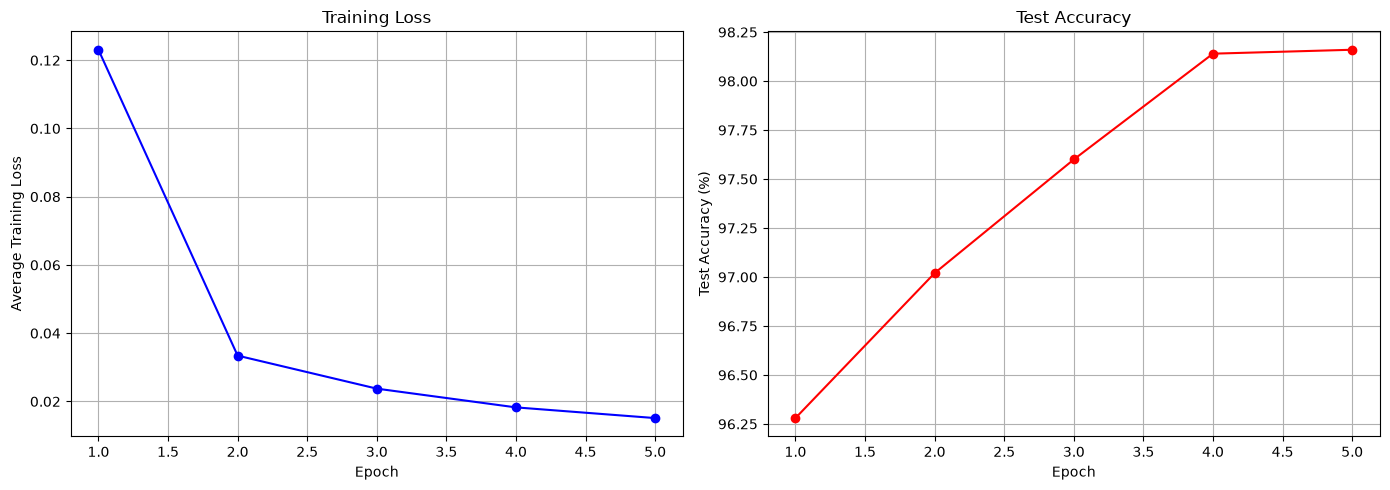

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(1, num_epochs+1), train_losses, 'b-o')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Average Training Loss'); ax1.set_title('Training Loss'); ax1.grid(True)
ax2.plot(range(1, num_epochs+1), test_accuracies, 'r-o')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Test Accuracy (%)'); ax2.set_title('Test Accuracy'); ax2.grid(True)
plt.tight_layout(); plt.savefig('training_curves.png', dpi=100, bbox_inches='tight'); plt.show()


### 10.2 Reconstruction Results

Input, prediction, and reconstruction for sample test images (replicating Figure 3).


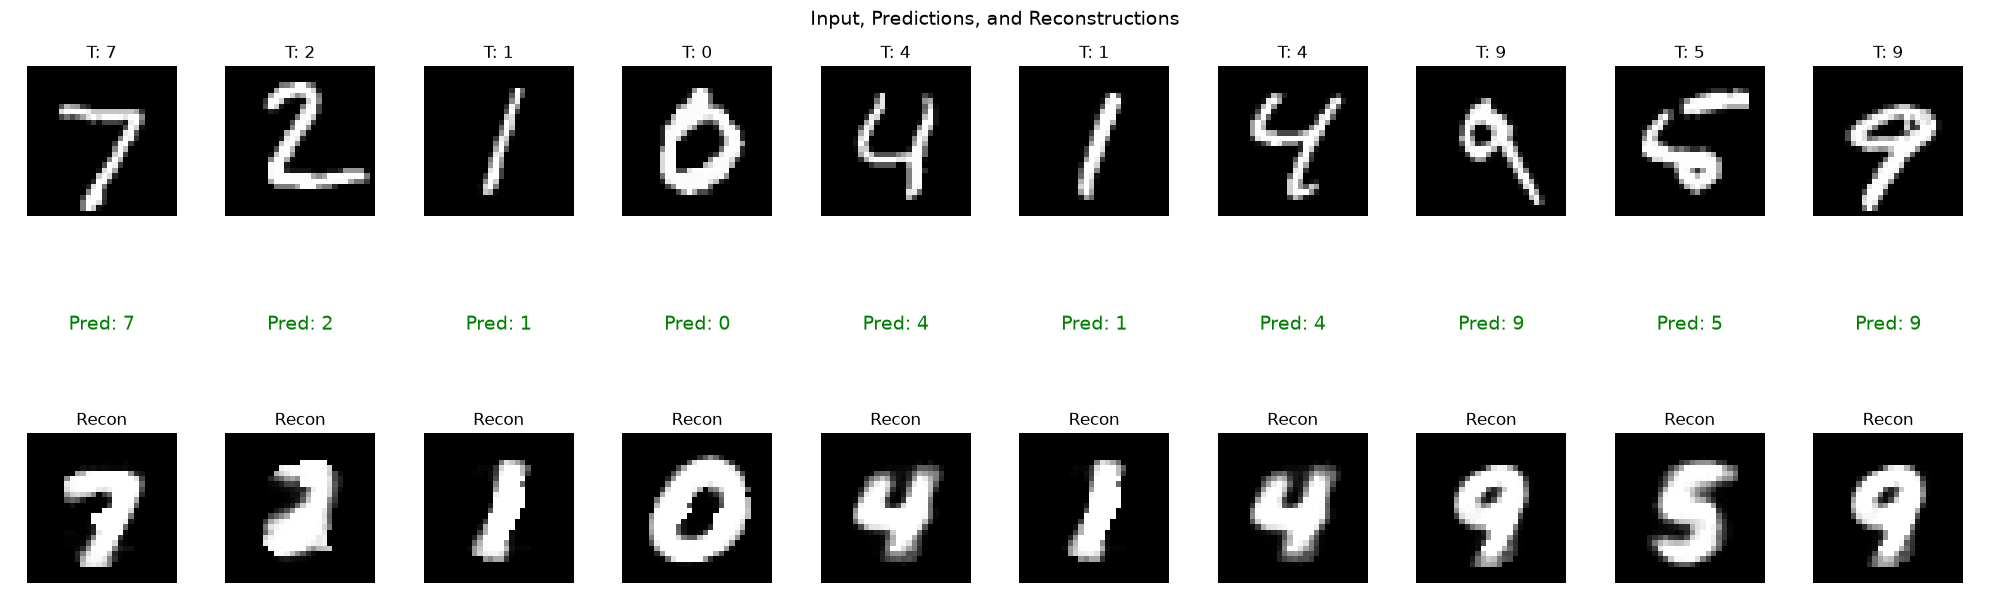

In [12]:
model.eval()
with torch.no_grad():
    data, labels = next(iter(test_loader))
    data, labels = data.to(device), labels.to(device)
    digit, recon = model(data, labels=None)
    preds = model.predict(data)

    fig, axes = plt.subplots(3, 10, figsize=(20, 6))
    for i in range(10):
        axes[0, i].imshow(data[i].cpu().squeeze(), cmap='gray')
        axes[0, i].set_title(f'T: {labels[i].item()}'); axes[0, i].axis('off')
        axes[1, i].text(0.5, 0.5, f'Pred: {preds[i].item()}', ha='center', va='center', fontsize=14,
                        color='green' if preds[i] == labels[i] else 'red'); axes[1, i].axis('off')
        axes[2, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
        axes[2, i].set_title('Recon'); axes[2, i].axis('off')
    axes[0, 0].set_ylabel('Input', fontsize=12)
    axes[2, 0].set_ylabel('Reconstruction', fontsize=12)
    plt.suptitle('Input, Predictions, and Reconstructions', fontsize=14)
    plt.tight_layout(); plt.savefig('reconstruction_results.png', dpi=100, bbox_inches='tight'); plt.show()


### 10.3 Dimension Perturbation — What Does Each Capsule Dimension Encode?

Replicating Figure 4: perturb each of the 8 dimensions and reconstruct.


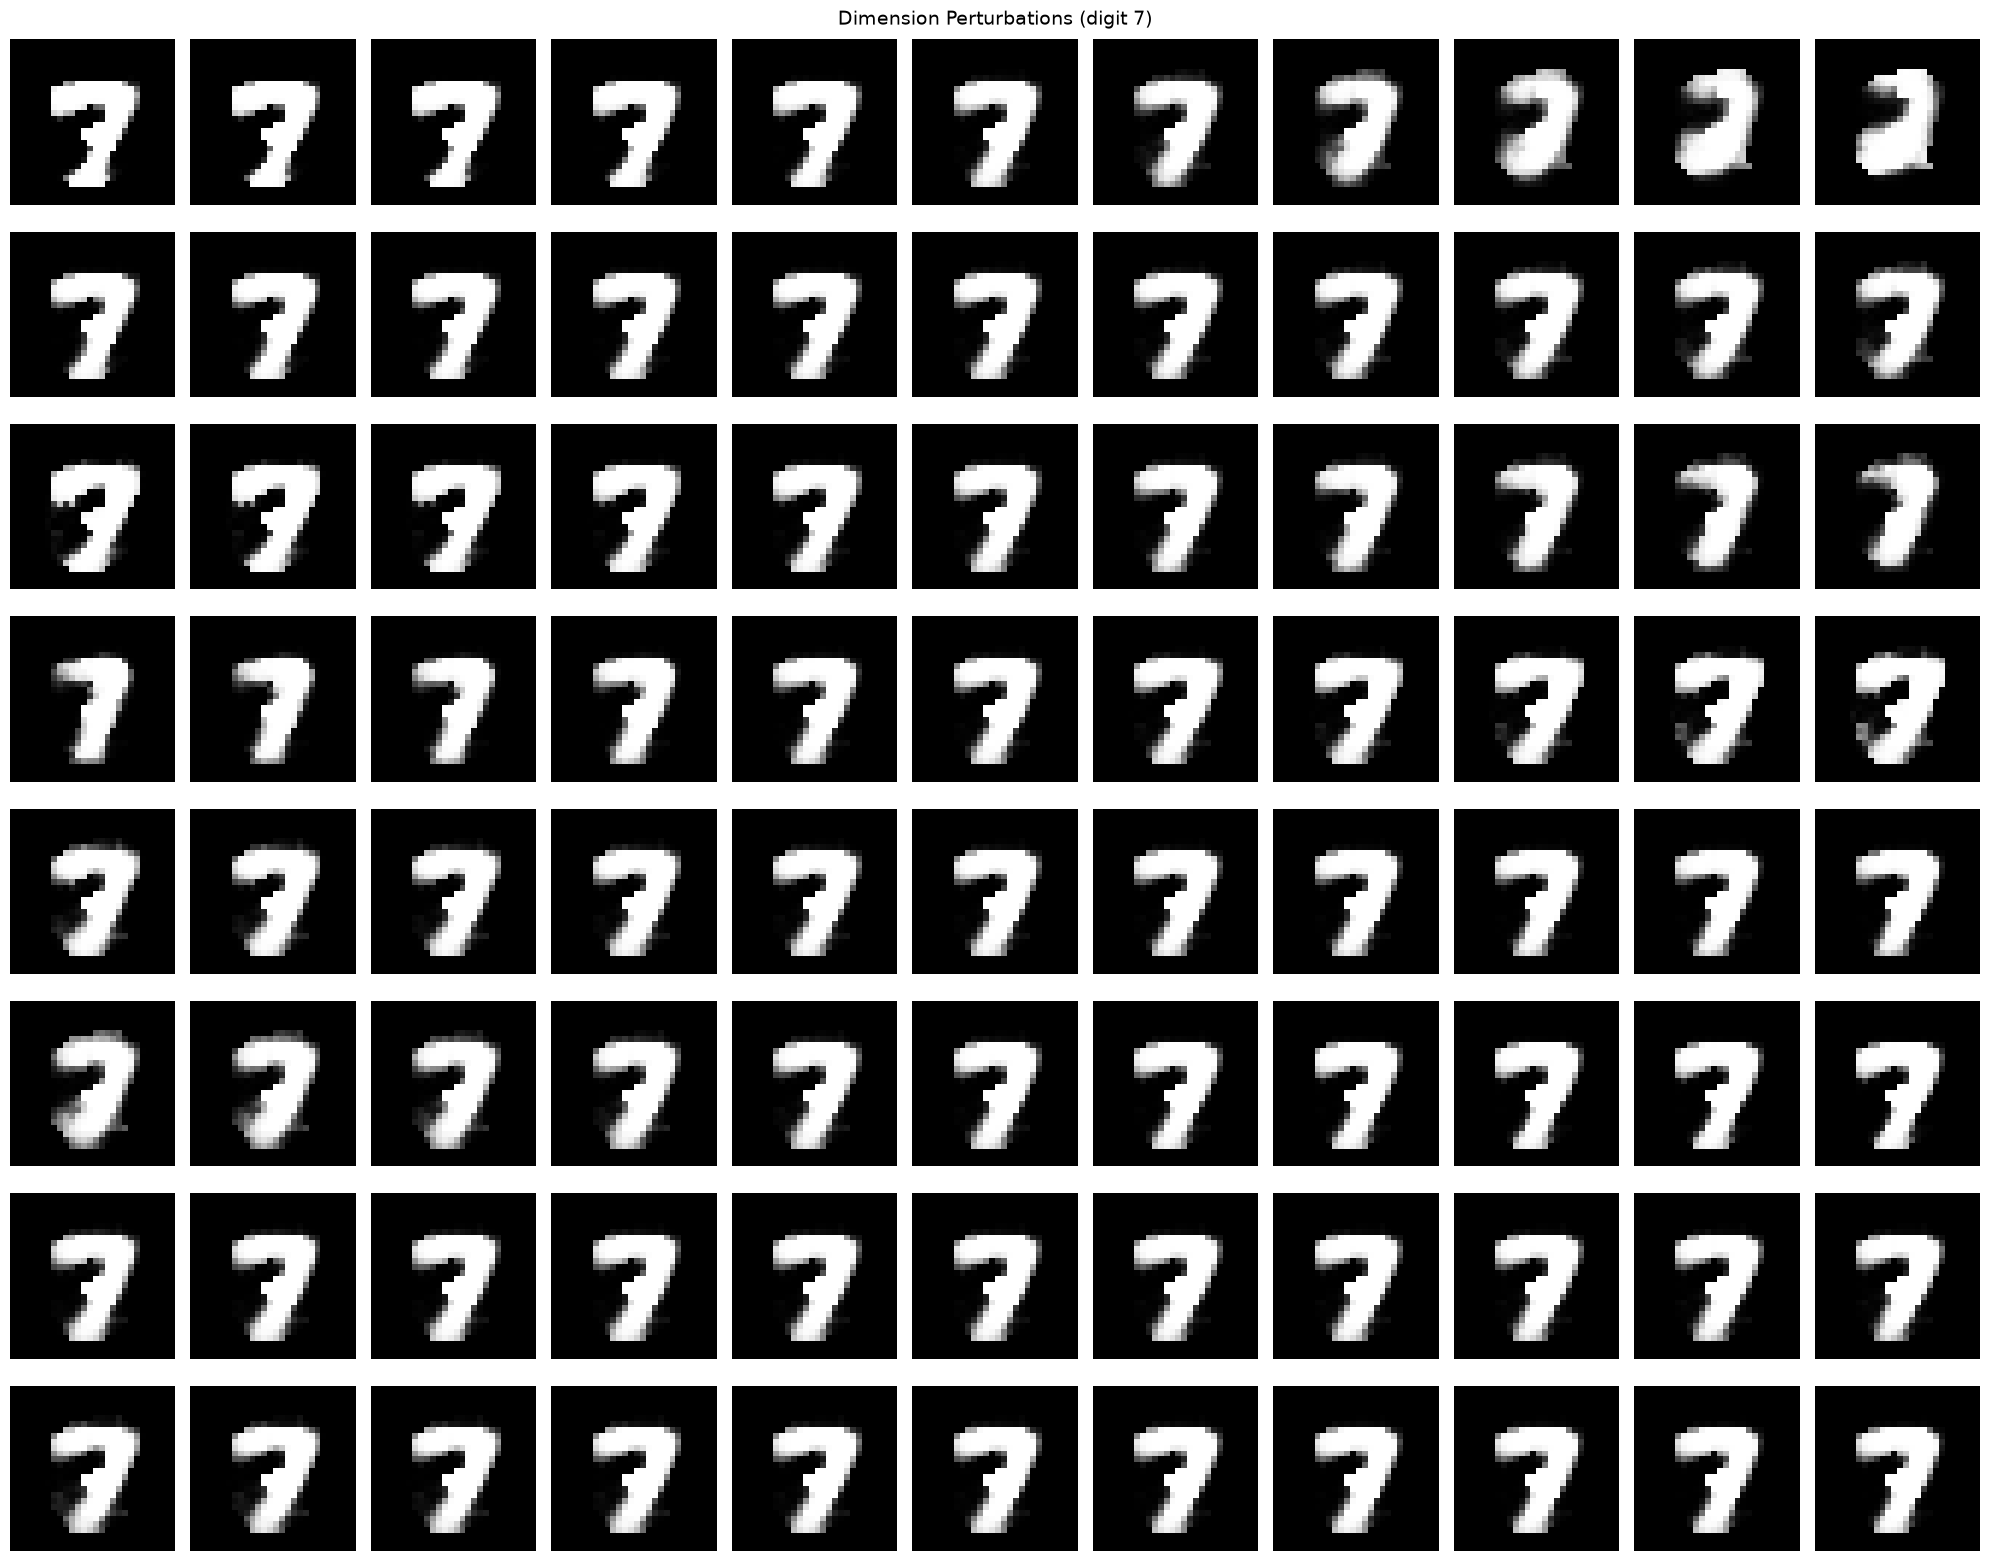

Each row shows reconstructions when one of the 8 DigitCaps dimensions
is perturbed. Observe how different dimensions control different visual properties.


In [13]:
model.eval()
with torch.no_grad():
    data, labels = next(iter(test_loader))
    data, labels = data.to(device), labels.to(device)
    digit, _ = model(data, labels=None)
    preds = model.predict(data)
    correct_idx = (preds == labels).nonzero(as_tuple=True)[0]
    sample_idx = correct_idx[0].item() if len(correct_idx) > 0 else 0
    true_label = labels[sample_idx].item()
    v = digit[sample_idx, true_label].clone()  # [8]

    perturbations = torch.linspace(-0.25, 0.25, 11)
    fig, axes = plt.subplots(8, 11, figsize=(20, 16))
    for dim in range(8):
        for j, pert in enumerate(perturbations):
            v_perturbed = v.clone()
            v_perturbed[dim] += pert
            recon = model.decoder(v_perturbed.unsqueeze(0))
            axes[dim, j].imshow(recon.cpu().squeeze(), cmap='gray')
            axes[dim, j].axis('off')
            if j == 0:
                axes[dim, j].set_ylabel(f'Dim {dim}', fontsize=10, rotation=0, labelpad=30)
    plt.suptitle(f'Dimension Perturbations (digit {true_label})', fontsize=14)
    plt.tight_layout(); plt.savefig('dimension_perturbations.png', dpi=100, bbox_inches='tight'); plt.show()
    print('Each row shows reconstructions when one of the 8 DigitCaps dimensions')
    print('is perturbed. Observe how different dimensions control different visual properties.')


## Summary

This notebook implemented a complete Capsule Network from scratch:

1. **Vector-output capsules** with the squashing non-linearity
2. **Dynamic routing-by-agreement** (2 iterations)
3. **Margin loss** for digit existence classification
4. **Reconstruction decoder** as a regularizer
5. **Visualization** of training curves, reconstructions, and dimension perturbations

**Scaling notes:** The architecture is reduced from the paper (64 vs 256 Conv1 channels, 8 vs 32 primary capsule types, 4D vs 8D primary vectors, 8D vs 16D digit vectors, 2 vs 3 routing iterations) for CPU-friendly execution. The core algorithm — squashing, routing-by-agreement, margin loss, and reconstruction regularization — is implemented exactly as described in the paper.

**Paper:** [Sabour, Frosst & Hinton (2017)](https://arxiv.org/abs/1710.09829)
